# IDM Run 3 — analysis workflow walkthrough

A hands-on tour of the `idm` package: the coffea-2025, **named-config** analysis flow.
By the end you will know **what to edit, where** to add an object, a cut, or a histogram,
how to run the analysis in-process, and how to make a CMS-style plot.

This is the **local / in-process** path: it loads one ntuple with `NanoEventsFactory.from_root`
and calls `IdmProcessor(...).process(events)` directly (no dask). For the distributed
HTCondor-backed run, see [`02_lpc_dask_example.ipynb`](02_lpc_dask_example.ipynb).

**Prerequisites:** the `idm_venv` environment + the `IDM (LCG_107 Py3.11)` Jupyter kernel
(see [`SETUP_Run3.md`](../../SETUP_Run3.md)). Select that kernel for this notebook. It runs
from any working directory (`idm` is pip-installed).

**The big idea:** you define analysis content *once, by name* in `idm/definitions/`, and you
*select by name* when you run. A new study changes **configuration**, not analysis code.

## 0. Imports

The ntuple **schema** (`MySchema`) and the analysis package both live under `idm/`, which is
pip-installed (`pip install -e .`), so everything imports cleanly with no `sys.path` juggling —
this notebook runs from any working directory.

In [1]:
import os

import awkward as ak
import matplotlib.pyplot as plt
from coffea.nanoevents import NanoEventsFactory

from idm.schema import MySchema
from idm.tools.processor import IdmProcessor
from idm.tools import plotting
from idm.definitions.cuts import cut_defs
from idm.definitions.hists import hist_defs

plotting.use_cms_style()
%matplotlib inline

/tmp/ipykernel_984700/442407742.py:5: DeprecationWarning: NanoEventsFactory.from_root() behavior has changed.
    The default behavior is that now it reads the input root file using
    the newly developed virtual arrays backend of awkward instead of dask.
    The backend choice is controlled by the `mode` argument of the method
    which can be set to "eager", "virtual", or "dask".
    The new default is "virtual" while the `delayed` argument has been removed.
    The old `delayed=True` is now equivalent to `mode="dask"`.
    The old `delayed=False` is now equivalent to `mode="eager"`.
    
  from coffea.nanoevents import NanoEventsFactory


## 1. Load an ntuple

The **schema** (`MySchema`) reads the flat ROOT ntuple (`TTree "ntuples/outT"`) and turns its
branches into physics-object collections you can use directly — `events.Electron`, `events.Muon`,
and so on. The default below is a small public example ntuple on EOS (read over xrootd);
override it by exporting `IDM_TUTORIAL_NTUPLE` before launching the kernel.

In [2]:
# A small example flat ntuple (TTree "ntuples/outT") on EOS, read over xrootd.
# Override with the IDM_TUTORIAL_NTUPLE env var to point at your own file.
DEFAULT_NTUPLE = (
    'root://cmseos.fnal.gov//store/group/lpcmetx/IDM_Run3/examples/'
    'tutorial_DYJets_2022PostEE.root'
)
ntuple_path = os.environ.get('IDM_TUTORIAL_NTUPLE', DEFAULT_NTUPLE)

events = NanoEventsFactory.from_root(
    {ntuple_path: 'ntuples/outT'}, schemaclass=MySchema,
).events()

# the object collections the schema built:
print(f'{len(events)} events')
sorted(events.fields)

2161 events


['APV',
 'CaloMET',
 'Conversion',
 'Electron',
 'GenJet',
 'GenMET',
 'GenPart',
 'HEM',
 'LptElectron',
 'METFiltersFailBits',
 'Muon',
 'PFJet',
 'PFMET',
 'PV',
 'Photon',
 'anyB',
 'eventNum',
 'fixedGridRhoFastjetAll',
 'genPU',
 'genWgt',
 'lumiSec',
 'nDSAMuon',
 'nPFJetAll',
 'numPFJetTaggedB',
 'numPFJetTrueB',
 'numPV',
 'ootPhoton',
 'passHEMveto',
 'recoDSAMuonCharge',
 'recoDSAMuonDisplacedId',
 'recoDSAMuonDxy',
 'recoDSAMuonDxyError',
 'recoDSAMuonDz',
 'recoDSAMuonDzError',
 'recoDSAMuonE',
 'recoDSAMuonEta',
 'recoDSAMuonEtaErr',
 'recoDSAMuonIdx',
 'recoDSAMuonOuterEta',
 'recoDSAMuonOuterPhi',
 'recoDSAMuonPhi',
 'recoDSAMuonPhiErr',
 'recoDSAMuonPt',
 'recoDSAMuonPtErr',
 'recoDSAMuonPx',
 'recoDSAMuonPy',
 'recoDSAMuonPz',
 'recoDSAMuonTrkChi2',
 'recoDSAMuonTrkNumCSCHits',
 'recoDSAMuonTrkNumDTHits',
 'recoDSAMuonTrkNumHits',
 'recoDSAMuonTrkNumPixHits',
 'recoDSAMuonTrkNumPlanes',
 'recoDSAMuonTrkNumStripHits',
 'recoDSAMuonTrkNumTrackerHits',
 'recoDSAMuonTrkPr

## 2. Look at the objects

Each collection is a jagged array (a variable-length list per event). You can read any field
and do columnar maths on it — no event loops.

In [3]:
print('muons / event :', ak.to_list(ak.num(events.Muon, axis=1))[:10])
print('a few muon pT  :', [round(p, 1) for p in ak.to_list(ak.flatten(events.Muon.pt))[:8]], 'GeV')

muons / event : [0, 0, 2, 0, 0, 0, 0, 0, 2, 2]
a few muon pT  : [15.3, 8.2, 39.9, 4.5, 6.0, 3.7, 8.0, 160.2] GeV


## 3. The named-config flow — *what to edit, where*

All analysis content lives in three files, as dictionaries of **named** callables:

| file | dict | each entry is |
|---|---|---|
| `idm/definitions/objects.py` | `obj_defs` | `name → f(events)` returning a collection |
| `idm/definitions/cuts.py`    | `cut_defs`  | `name → f(events)` returning a per-event mask |
| `idm/definitions/hists.py`   | `hist_defs` | `name → {"axis": <hist.axis>, "fill": f(events) → array}` |

**To add a histogram**, add one entry to `hist_defs`. **To add a cut**, add to `cut_defs`.
That is the whole edit — nothing in the processor changes.

In [4]:
print('available cuts :', list(cut_defs))
print('available hists:', list(hist_defs))
hist_defs['muon_pt']   # peek at one definition

available cuts : ['has_electron', 'has_muon']
available hists: ['n_electron', 'electron_pt', 'muon_pt']


{'axis': Regular(50, 0, 100, name='pt', label='PF muon $p_{T}$ [GeV]'),
 'fill': <function idm.definitions.hists.<lambda>(e)>}

## 4. Run the analysis — *select by name*

`IdmProcessor` AND-s the chosen cuts into an event selection, fills the chosen histograms, and
returns them with a cutflow. You choose *which* by name — the same engine runs any configuration.
This is the **in-process** call (`process(events)`); the dask notebook drives the very same
`IdmProcessor` through coffea's `Runner` across many Condor workers.

In [5]:
p = IdmProcessor(cuts=['has_muon'], hists=['muon_pt', 'n_electron'])
out = p.process(events)
print('cutflow:', out['cutflow'])
out['hists']['muon_pt']

cutflow: {'all': 2161, 'has_muon': 1262}


Hist(Regular(50, 0, 100, name='pt', label='PF muon $p_{T}$ [GeV]'), storage=Double()) # Sum: 2130.0 (2308.0 with flow)

## 5. Plot it (CMS style)

Use the `idm.tools.plotting` helpers so every plot follows the same CMS / mplhep conventions
(figure size, CMS label, com=13.6 TeV for Run 3).

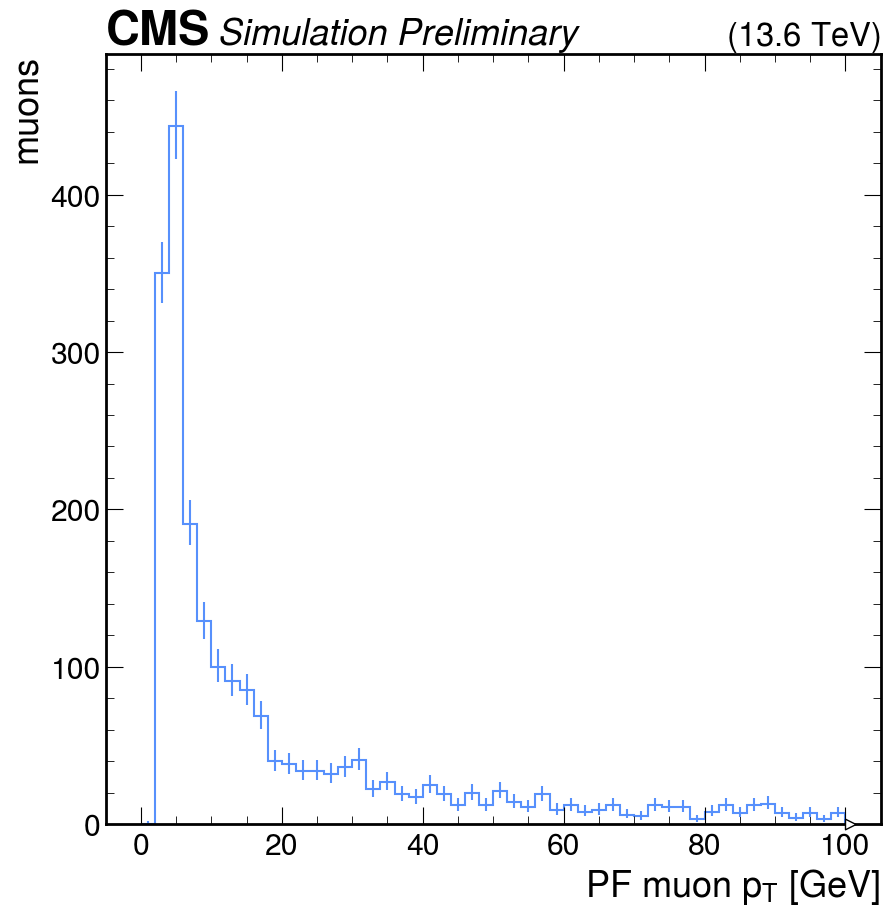

In [6]:
fig, ax = plotting.new_figure()
plotting.plot_hist(out['hists']['muon_pt'], ax=ax, histtype='step')
ax.set_xlabel(r'PF muon $p_{T}$ [GeV]')
ax.set_ylabel('muons')
plotting.cms_label(ax, data=False, com=13.6)
plt.show()

## 6. Scaling up & provenance (pointers)

- **Run distributed** over many files on LPC HTCondor: build a client with
  `idm.tools.scaleout.make_lpc_client()` and drive the same `IdmProcessor` with coffea's
  `Runner` + `DaskExecutor`. See [`02_lpc_dask_example.ipynb`](02_lpc_dask_example.ipynb).
- **Record provenance** for an output: `idm.tools.metadata.write_run_metadata(...)` writes a
  `.meta.yaml` sidecar (fileset, git commit, coffea version, schema) next to your `.coffea`.

## Recap — what to edit, where

| To add a… | edit | then run with |
|---|---|---|
| object | `idm/definitions/objects.py` | (referenced by cuts/hists) |
| cut | `idm/definitions/cuts.py` | `IdmProcessor(cuts=[...])` |
| histogram | `idm/definitions/hists.py` | `IdmProcessor(hists=[...])` |

You only ever edit the **named definitions** — `idm/tools/processor.py` stays the same.